# Matplotlib & Seaborn — Visualización de Datos

## ¿Qué es Matplotlib?

**Matplotlib** es la librería de visualización más popular de Python. Permite crear gráficas de publicación científica con control total sobre cada elemento visual.

- Es muy **flexible** y **poderosa**
- Algo verbosa: requiere varias líneas para hacer una gráfica detallada
- Base de muchas otras librerías de visualización

## ¿Qué es Seaborn?

**Seaborn** está construida **sobre** Matplotlib. Su objetivo es hacer visualizaciones estadísticas atractivas con menos código.

- Gráficas más **estéticas** por defecto
- Integración directa con **DataFrames de Pandas**
- Ideal para **análisis exploratorio de datos**

| Característica | Matplotlib | Seaborn |
|---|---|---|
| Control | Total | Moderado |
| Código necesario | Más | Menos |
| Estética por defecto | Básica | Profesional |
| Integración con Pandas | Manual | Directa |

## Instalación e Importación

```bash
pip install matplotlib seaborn
```

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Esta línea hace que las gráficas se muestren dentro del notebook
%matplotlib inline

print("Matplotlib versión:", __import__('matplotlib').__version__)
print("Seaborn versión:", sns.__version__)

Matplotlib versión: 3.8.0
Seaborn versión: 0.12.2


---
## Parte 1 — Matplotlib

### Nivel 1: Gráfica de línea básica

In [ ]:
# La gráfica más simple posible
x = [1, 2, 3, 4, 5]
y = [2, 4, 3, 6, 5]

plt.plot(x, y)
plt.show()

In [ ]:
# Gráfica de línea con personalización
x = np.linspace(0, 2 * np.pi, 100)  # 100 puntos entre 0 y 2π
y_sin = np.sin(x)
y_cos = np.cos(x)

plt.figure(figsize=(10, 4))  # Tamaño en pulgadas (ancho, alto)

plt.plot(x, y_sin, color="blue",   linewidth=2, label="sen(x)")
plt.plot(x, y_cos, color="red",    linewidth=2, label="cos(x)", linestyle="--")

plt.title("Funciones trigonométricas", fontsize=14)
plt.xlabel("x (radianes)")
plt.ylabel("y")
plt.legend()           # Mostrar leyenda
plt.grid(True, alpha=0.3)  # Líneas de cuadrícula
plt.axhline(0, color='black', linewidth=0.5)  # Línea en y=0

plt.tight_layout()
plt.show()

### Nivel 2: Gráfica de barras

In [ ]:
carreras = ["Física", "Matemática", "Computación", "Biología", "Química"]
estudiantes = [45, 38, 62, 29, 33]

plt.figure(figsize=(9, 5))

barras = plt.bar(carreras, estudiantes, color=["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"])

# Agregar el valor encima de cada barra
for barra, valor in zip(barras, estudiantes):
    plt.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.5,
             str(valor), ha='center', va='bottom', fontweight='bold')

plt.title("Estudiantes por carrera")
plt.xlabel("Carrera")
plt.ylabel("Número de estudiantes")
plt.ylim(0, 75)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Nivel 2: Histograma y gráfica de dispersión

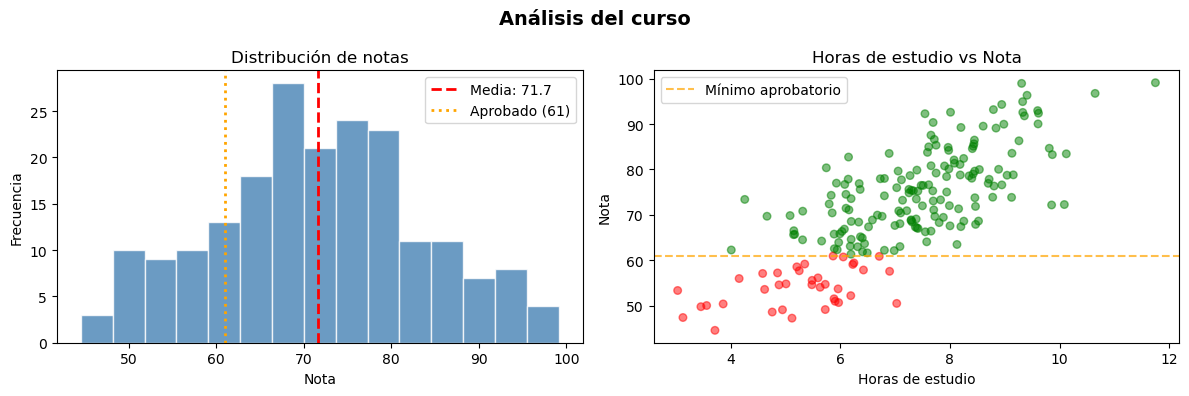

In [2]:
# Datos: notas simuladas de 200 estudiantes
np.random.seed(7)
notas = np.random.normal(loc=72, scale=12, size=200).clip(0, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 fila, 2 columnas

# --- Histograma ---
axes[0].hist(notas, bins=15, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(notas.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {notas.mean():.1f}')
axes[0].axvline(61, color='orange', linestyle=':', linewidth=2, label='Aprobado (61)')
axes[0].set_title("Distribución de notas")
axes[0].set_xlabel("Nota")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# --- Dispersión (scatter) ---
horas_estudio = notas / 10 + np.random.normal(0, 1, 200)
horas_estudio = horas_estudio.clip(0, 15)

colores = ['green' if n >= 61 else 'red' for n in notas]
axes[1].scatter(horas_estudio, notas, c=colores, alpha=0.5, s=30)
axes[1].set_title("Horas de estudio vs Nota")
axes[1].set_xlabel("Horas de estudio")
axes[1].set_ylabel("Nota")
axes[1].axhline(61, color='orange', linestyle='--', alpha=0.7, label='Mínimo aprobatorio')
axes[1].legend()

plt.suptitle("Análisis del curso", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Nivel 3: Subplots — múltiples gráficas

In [ ]:
# Gráfica de pastel (pie chart)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
aprobados = int(np.sum(notas >= 61))
reprobados = len(notas) - aprobados

axes[0].pie(
    [aprobados, reprobados],
    labels=[f"Aprobados\n({aprobados})", f"Reprobados\n({reprobados})"],
    colors=["#2ecc71", "#e74c3c"],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0)
)
axes[0].set_title("Resultado del curso")

# Box plot (diagrama de caja)
datos_por_zona = {
    "Reprobado\n(<61)": notas[notas < 61],
    "Aprobado\n(61-79)": notas[(notas >= 61) & (notas < 80)],
    "Excelente\n(80+)": notas[notas >= 80]
}

axes[1].boxplot(datos_por_zona.values(), labels=datos_por_zona.keys(),
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Distribución por zona")
axes[1].set_ylabel("Nota")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Parte 2 — Seaborn

Seaborn trabaja mejor con DataFrames de Pandas. Primero creamos un dataset de ejemplo:

In [ ]:
# Crear dataset de ejemplo
np.random.seed(42)
n = 120

df = pd.DataFrame({
    "Nombre":    [f"Est_{i:03d}" for i in range(n)],
    "Carrera":   np.random.choice(["Física", "Matemática", "Computación"], size=n),
    "Semestre":  np.random.choice([1, 2, 3, 4, 5, 6, 7, 8], size=n),
    "Horas_estudio": np.random.normal(5, 2, n).clip(0, 12).round(1),
    "Nota":      np.random.normal(72, 14, n).clip(40, 100).round(1),
})

# La nota mejora levemente con las horas de estudio
df["Nota"] = (df["Nota"] + df["Horas_estudio"] * 1.5).clip(40, 100).round(1)
df["Estado"] = df["Nota"].apply(lambda n: "Aprobado" if n >= 61 else "Reprobado")

print("Dataset creado:")
print(df.head())
print(f"\nShape: {df.shape}")

### Nivel 1: Configurar el estilo de Seaborn

In [ ]:
# Seaborn tiene varios temas predefinidos
# whitegrid, darkgrid, white, dark, ticks
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

print("Tema configurado. Las siguientes gráficas usarán este estilo.")

### Nivel 2: Distribuciones

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# histplot: histograma mejorado con curva de densidad
sns.histplot(data=df, x="Nota", hue="Estado",
             bins=20, kde=True, palette={"Aprobado": "#2ecc71", "Reprobado": "#e74c3c"},
             ax=axes[0])
axes[0].axvline(61, color='black', linestyle='--', linewidth=1.5, label='Mínimo (61)')
axes[0].set_title("Distribución de notas")
axes[0].legend()

# boxplot comparativo por carrera
sns.boxplot(data=df, x="Carrera", y="Nota", hue="Carrera",
            palette="Set2", ax=axes[1], legend=False)
axes[1].axhline(61, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_title("Notas por carrera")

plt.tight_layout()
plt.show()

### Nivel 3: Relaciones entre variables

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatterplot con línea de regresión
sns.regplot(data=df, x="Horas_estudio", y="Nota",
            scatter_kws={'alpha': 0.4, 's': 30},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=axes[0])
axes[0].set_title("Horas de estudio vs Nota")
axes[0].set_xlabel("Horas de estudio diarias")
axes[0].set_ylabel("Nota final")

# violinplot — muestra distribución más detalladamente que boxplot
sns.violinplot(data=df, x="Carrera", y="Nota", hue="Carrera",
               palette="Pastel1", inner="quartile",
               ax=axes[1], legend=False)
axes[1].set_title("Distribución de notas por carrera")

plt.tight_layout()
plt.show()

### Nivel 4: Heatmap — mapa de calor

In [ ]:
# Heatmap de correlación entre variables numéricas
correlacion = df[["Horas_estudio", "Nota", "Semestre"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    correlacion,
    annot=True,        # Mostrar valores en las celdas
    fmt=".2f",         # Formato: 2 decimales
    cmap="coolwarm",   # Paleta de colores (azul = negativo, rojo = positivo)
    center=0,          # Centro de la escala en 0
    square=True,       # Celdas cuadradas
    linewidths=0.5
)
plt.title("Correlación entre variables")
plt.tight_layout()
plt.show()

### Nivel 5: Dashboard completo — combinando todo

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Dashboard: Análisis del Curso", fontsize=16, fontweight='bold', y=1.01)

# 1. Distribución general de notas
sns.histplot(data=df, x="Nota", bins=18, kde=True, color="steelblue", ax=axes[0, 0])
axes[0, 0].axvline(df["Nota"].mean(), color='red', linestyle='--', label=f'Media: {df["Nota"].mean():.1f}')
axes[0, 0].set_title("Distribución de notas")
axes[0, 0].legend()

# 2. Resultado por carrera (barras apiladas)
resultado = df.groupby(["Carrera", "Estado"]).size().unstack(fill_value=0)
resultado.plot(kind='bar', ax=axes[0, 1], color=["#e74c3c", "#2ecc71"],
               edgecolor='white', rot=0)
axes[0, 1].set_title("Aprobados vs Reprobados por carrera")
axes[0, 1].set_xlabel("")
axes[0, 1].legend(title="")

# 3. Dispersión horas vs nota
sns.scatterplot(data=df, x="Horas_estudio", y="Nota",
                hue="Carrera", style="Estado", alpha=0.6, ax=axes[0, 2])
axes[0, 2].axhline(61, color='black', linestyle=':', linewidth=1)
axes[0, 2].set_title("Horas de estudio vs Nota")

# 4. Boxplot por semestre (pares e impares)
sns.boxplot(data=df, x="Semestre", y="Nota", palette="Blues", ax=axes[1, 0])
axes[1, 0].axhline(61, color='red', linestyle='--', alpha=0.6)
axes[1, 0].set_title("Notas por semestre")

# 5. Violinplot por carrera
sns.violinplot(data=df, x="Carrera", y="Nota", hue="Carrera",
               palette="Set3", inner="box", ax=axes[1, 1], legend=False)
axes[1, 1].set_title("Distribución por carrera")

# 6. Heatmap de correlación
corr = df[["Horas_estudio", "Nota", "Semestre"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=axes[1, 2], square=True, linewidths=0.5)
axes[1, 2].set_title("Correlación")

plt.tight_layout()
plt.show()

---
## Guardar gráficas

Para guardar una gráfica como imagen, usa `plt.savefig()` **antes** de `plt.show()`:

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Carrera", y="Nota", hue="Carrera",
            palette="Set2", errorbar="sd", legend=False)
plt.title("Promedio de notas por carrera")
plt.ylabel("Nota promedio")

# Guardar la gráfica (dpi=150 para buena resolución)
plt.savefig("/tmp/grafica_notas.png", dpi=150, bbox_inches="tight")
print("Gráfica guardada en /tmp/grafica_notas.png")

plt.tight_layout()
plt.show()